['hello', 'world']

['hello', 'atguigu']

['hello', 'llm']

2026-08-13 16:06:10.414 | INFO     | __main__:reducer_node:66 - reducer shuffle entries:{'hello': [1, 1, 1]}
2026-08-13 16:06:10.414 | INFO     | __main__:reducer_node:72 - reducer {'hello': 3}


{
    'input_values': ['hello world', 'hello atguigu', 'hello llm'],
    'entries': [('hello', 1), ('hello', 1), ('hello', 1)],
    'word_counts': {'hello': 3}
}

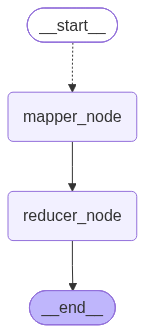

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	mapper_node(mapper_node)
	reducer_node(reducer_node)
	__end__([<p>__end__</p>]):::last
	__start__ -.-> mapper_node;
	mapper_node --> reducer_node;
	reducer_node --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [1]:
from typing import TypedDict, Annotated, Sequence
from rich import print as rprint
from langgraph.constants import START,END
from langgraph.graph import StateGraph
from langgraph.types import Send
from operator import add
from loguru import logger

#1. 声明状态
#1.1 声明全局状态
class OverAllState(TypedDict):
    input_values: list[str]
    entries:Annotated[list[tuple[str,int]],add]
    word_counts:dict[str,int]

class MaperInputState(TypedDict):
    input_value:str
    
# 定义 Mapper 节点专属的输出 State
class MapperOutputState(TypedDict):
    entries: list[tuple[str, int]]

#2. 声明节点
#2.1 分发节点
def router_node(state: OverAllState) -> Sequence[Send]:
    # 使用 .get() 避免 KeyMissing 报错，并防御空列表
    input_values = state.get("input_values", [])

    if not input_values:
        # 如果没有输入数据，可以打印日志提示或返回空列表终止
        return []

    return [
        Send("mapper_node", {"input_value": input_value})
        for input_value in input_values
    ]

#2.2 接收单独的一句话, 切分为单词  组装为元组放到全局状态中
# def mapper_node(state: MaperInputState) -> MapperOutputState:
#     entries = [(word, 1) for word in state["input_value"].split()]
#     return {"entries": entries}

def mapper_node(state:MaperInputState) -> OverAllState:
    input_value = state["input_value"]
    words = input_value.split(" ")
    rprint(words)
    # (hello, 1), (world, 1)
    entries = []
    for word in words:
        entries.append((word,1))
        return {
        "entries":entries
        }

#2.3 聚合所有的mapper_node拆分的元组进行合并
def reducer_node(state:OverAllState) -> OverAllState:
    entries = state["entries"]
    shuffle_dict = {}
    # hello   -> [1, 1, 1]
    for k,v in entries:
        if k not in shuffle_dict:
            shuffle_dict[k] = [v]
        else:
            shuffle_dict[k].append(v)

    logger.info("reducer shuffle entries:{}",shuffle_dict)
    reduce_dict = {}

    for k,v in shuffle_dict.items():
        reduce_dict[k] = sum(v)

    logger.info("reducer {}",reduce_dict)

    return {
        "word_counts":reduce_dict
    }

#3. 构件图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("mapper_node",mapper_node)
builder.add_node("reducer_node",reducer_node)
builder.add_conditional_edges(START,router_node,path_map=["mapper_node"])
builder.add_edge("mapper_node","reducer_node")
builder.add_edge("reducer_node",END)
graph = builder.compile()

res = graph.invoke({
    "input_values":["hello world","hello atguigu","hello llm"]
})
rprint(res)

from IPython.display import display
display(graph)
raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)
